<a href="https://colab.research.google.com/github/jedidiahramos/DiscreteMathClustering/blob/main/bag_of_words_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bag-of-Words

In [ ]:
# Install required packages
!pip install scikit-learn matplotlib plotly --quiet

import json
import time
import numpy as np
import plotly.graph_objects as go
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from google.colab import files

# ================== Tokenization Code ==================

def insert_token(result, opening_char, token):
    while result[-1] != opening_char:
        result.pop()
    result.pop()
    for token_char in token:
        result.append(token_char)

def tokenize_tuples(text):
    result = []
    stack = []
    for char in text:
        result.append(char)
        if char == '(':
            stack.append(char)
        elif char == ',':
            if stack and stack[-1] == '(':
                stack[-1] = char
        elif char == ')' and stack:
            if stack[-1] == ',':
                insert_token(result, '(', '[tuple]')
            stack.pop()
    return ''.join(result)

def tokenize_relations(text):
    result = []
    stack = []
    for char in text:
        result.append(char)
        if char == '{':
            if stack and stack[-1] != '{' and stack[-1] != ']':
                stack.pop()
            stack.append(char)
        elif stack:
            if (stack[-1] == '{' and char == '[') or \
            (stack[-1] == '[' and char == 't') or \
            (stack[-1] == 't' and char == 'u') or \
            (stack[-1] == 'u' and char == 'p') or \
            (stack[-1] == 'p' and char == 'l') or \
            (stack[-1] == 'l' and char == 'e') or \
            (stack[-1] == 'e' and char == ']'):
                stack[-1] = char
            elif char == '}' and stack[-1] == ']':
                insert_token(result, '{', '[relation]')
                stack.pop()
            elif stack[-1] != '{' and stack[-1] != ']':
                stack.pop()
    return ''.join(result)

def tokenize_sets(text):
    result = []
    stack = []
    for char in text:
        result.append(char)
        if char == '{':
            stack.append(char)
        elif char == '}' and stack:
            insert_token(result, '{', '[set]')
            stack.pop()
    return ''.join(result)

def tokenize_math_questions(text):
    return tokenize_sets(tokenize_relations(tokenize_tuples(text)))

# ================== Load and Preprocess Data ==================

def load_dataset(filename):
    with open(filename, 'r') as f:
        data = json.load(f)
    texts, labels = [], []
    for category, questions in data.items():
        for q in questions:
            tokenized = tokenize_math_questions(q)
            texts.append(tokenized)
            labels.append(category)
    return texts, labels

def classify_with_bow(dataset_name):
    uploaded = files.upload()

    # Filenames from upload
    training_data, test_data = list(uploaded.keys())

    X_train_raw, y_train = load_dataset(training_data)
    X_test_raw, y_test = load_dataset(test_data)

    # Encode category labels
    label_encoder = LabelEncoder()
    y_train_enc = label_encoder.fit_transform(y_train)
    y_test_enc = label_encoder.transform(y_test)

    # ================== N-gram Optimization ==================

    results = []
    best_n = 1
    best_acc = 0

    for n in range(1, 6):
        start_time = time.time()
        vectorizer = CountVectorizer(ngram_range=(n, n))
        X_train_vec = vectorizer.fit_transform(X_train_raw)

        model = MultinomialNB()
        model.fit(X_train_vec, y_train_enc)

        preds = model.predict(X_train_vec)
        acc = accuracy_score(y_train_enc, preds)

        elapsed = time.time() - start_time
        results.append((n, round(acc * 100, 2), round(elapsed, 2)))

        if acc > best_acc:
            best_acc = acc
            best_n = n

    # Display results table
    ngram_table = go.Figure(data=[go.Table(
        header=dict(values=["n-gram", "Accuracy (%)", "Time (s)"],
                    fill_color='paleturquoise'),
        cells=dict(values=[list(row) for row in zip(*results)],
                  fill_color='lavender'))
    ])
    ngram_table.update_layout(title_text=dataset_name + " N-gram Tuning Results", autosize=False)
    ngram_table.show()

    # ================== Final Training and Evaluation ==================

    vectorizer = CountVectorizer(ngram_range=(best_n, best_n))
    X_train_vec = vectorizer.fit_transform(X_train_raw)
    X_test_vec = vectorizer.transform(X_test_raw)

    model = MultinomialNB()
    model.fit(X_train_vec, y_train_enc)
    y_pred = model.predict(X_test_vec)

    # Accuracy
    acc = accuracy_score(y_test_enc, y_pred)
    print(f" Accuracy for Test Dataset: {acc * 100:.2f} %")

    # Confusion matrix
    conf_mat = confusion_matrix(y_test_enc, y_pred)
    categories = label_encoder.classes_

    # Show confusion matrix as Plotly table
    conf_fig = go.Figure(data=[go.Table(
        header=dict(values=[""] + list(categories),
                    fill_color='paleturquoise'),
        cells=dict(values=[list(categories)] + [conf_mat[:, i].tolist() for i in range(len(categories))],
                  fill_color='lavender'))
    ])
    conf_fig.update_layout(title_text=dataset_name + " Test Dataset Confusion Matrix", autosize=False)
    conf_fig.show()

    # Classification report
    precision, recall, f1, _ = precision_recall_fscore_support(y_test_enc, y_pred, zero_division=0)

    # Specificity calculation
    def compute_specificity(conf_matrix):
        specificities = []
        for i in range(len(conf_matrix)):
            tn = np.sum(np.delete(np.delete(conf_matrix, i, axis=0), i, axis=1))
            fp = np.sum(np.delete(conf_matrix[:, i], i))
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            specificities.append(specificity)
        return specificities

    specificity = compute_specificity(conf_mat)

    # Show classification metrics (in percentages, rounded to 2 decimal places)
    metrics_fig = go.Figure(data=[go.Table(
        header=dict(values=["Category", "Precision (%)", "Recall (%)", "F1 Score (%)", "Specificity (%)"],
                    fill_color='paleturquoise'),
        cells=dict(values=[
            categories,
            [f"{p * 100:.2f}" for p in precision],
            [f"{r * 100:.2f}" for r in recall],
            [f"{f * 100:.2f}" for f in f1],
            [f"{s * 100:.2f}" for s in specificity]
        ],
        fill_color='lavender'))
    ])
    metrics_fig.update_layout(title_text="Per-Category Classification Metrics (in %)", autosize=False)
    metrics_fig.show()

Unprocessed Questions

In [ ]:
classify_with_bow("Unprocessed Questions")

Saving first_20_math_questions.json to first_20_math_questions (6).json
Saving test_math_questions.json to test_math_questions (6).json


 Accuracy for Test Dataset: 58.82 %


In [ ]:
import plotly.graph_objects as go

precision = [1.00, 0.60, 0.73, 0.12]
recall = [0.36, 0.78, 0.70, 0.20]
f1 = [0.53, 0.68, 0.71, 0.15]
specificity = [1.00, 0.66, 0.92, 0.84]

# Show classification metrics (in percentages, rounded to 2 decimal places)
metrics_fig = go.Figure(data=[go.Table(
    header=dict(values=["Category", "Precision", "Recall", "F1 Score", "Specificity"],
                fill_color='paleturquoise'),
    cells=dict(values=[
        ['Formal Logic', 'Functions', 'Relations', 'Sets, Proofs, and Induction'],
        [f"{p:.2f}" for p in precision],
        [f"{r:.2f}" for r in recall],
        [f"{f:.2f}" for f in f1],
        [f"{s:.2f}" for s in specificity]
    ],
    fill_color='lavender'))
])
metrics_fig.update_layout(title_text="Bag-of-Words Unprocessed Questions Test Dataset Evaluation Metrics", autosize=False)
metrics_fig.show()

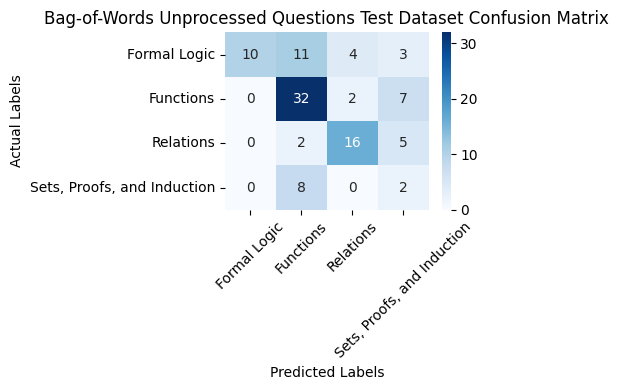

In [ ]:
# Install seaborn if not already installed (uncomment below if needed)
# !pip install seaborn

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Sample 4x4 confusion matrix (you can replace this with your actual matrix)
conf_matrix = np.array([
    [10, 11,  4,  3],
    [ 0, 32,  2,  7],
    [ 0,  2, 16,  5],
    [ 0,  8,  0,  2]
])

# Labels for your classes
labels = ['Formal Logic', 'Functions', 'Relations', 'Sets, Proofs, and Induction']

# Plotting the heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Bag-of-Words Unprocessed Questions Test Dataset Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
# Rotate x-axis labels
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

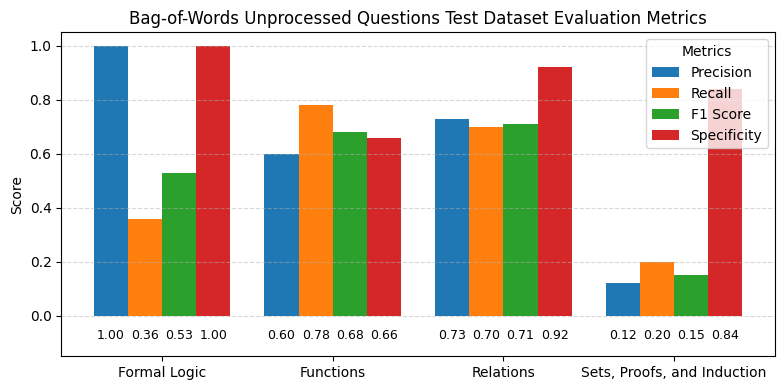

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data: 4 classes × 4 metrics
classes = ['Formal Logic', 'Functions', 'Relations', 'Sets, Proofs, and Induction']
metrics = ['Precision', 'Recall', 'F1 Score', 'Specificity']

# Random sample metric values (rows = classes, columns = metrics)
data = np.array([
    [1.00, 0.36, 0.53, 1.00],  # Class A
    [0.60, 0.78, 0.68, 0.66],  # Class B
    [0.73, 0.70, 0.71, 0.92],  # Class C
    [0.12, 0.20, 0.15, 0.84],  # Class D
])

# Plot settings
bar_width = 0.2
x = np.arange(len(classes))  # positions for each group
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(8, 4))

# Draw bars and add value labels below each bar (outside the bar)
for i in range(len(metrics)):
    bar_positions = x + i * bar_width
    bars = ax.bar(bar_positions, data[:, i], width=bar_width, label=metrics[i], color=colors[i])
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, -0.05, f'{height:.2f}',
                ha='center', va='top', fontsize=9, color='black')

# Axis configuration
ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(classes)
ax.set_ylabel('Score')
ax.set_ylim(-0.15, 1.05)  # extra space at bottom to accommodate labels
ax.set_title('Bag-of-Words Unprocessed Questions Test Dataset Evaluation Metrics')
ax.legend(title='Metrics')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Processed Questions

In [ ]:
classify_with_bow("Processed Questions")

Saving first_20_processed.json to first_20_processed.json
Saving test_processed_questions.json to test_processed_questions.json


 Accuracy for Test Dataset: 38.24 %


In [ ]:
import plotly.graph_objects as go

precision = [0.32, 0.69, 0.45, 0.15]
recall = [0.61, 0.27, 0.39, 0.20]
f1 = [0.42, 0.39, 0.42, 0.17]
specificity = [0.51, 0.92, 0.86, 0.88]

# Show classification metrics (in percentages, rounded to 2 decimal places)
metrics_fig = go.Figure(data=[go.Table(
    header=dict(values=["Category", "Precision", "Recall", "F1 Score", "Specificity"],
                fill_color='paleturquoise'),
    cells=dict(values=[
        ['Formal Logic', 'Functions', 'Relations', 'Sets, Proofs, and Induction'],
        [f"{p:.2f}" for p in precision],
        [f"{r:.2f}" for r in recall],
        [f"{f:.2f}" for f in f1],
        [f"{s:.2f}" for s in specificity]
    ],
    fill_color='lavender'))
])
metrics_fig.update_layout(title_text="Bag-of-Words Processed Questions Test Dataset Evaluation Metrics", autosize=False)
metrics_fig.show()

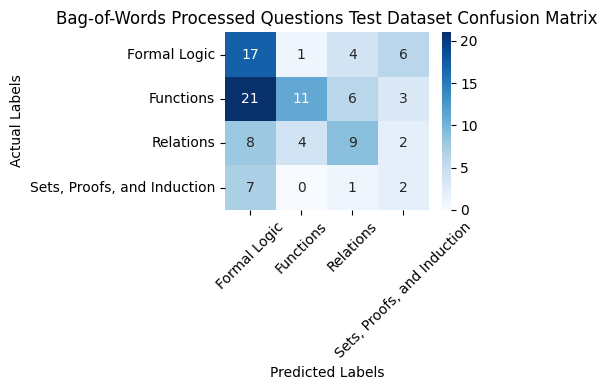

In [ ]:
# Install seaborn if not already installed (uncomment below if needed)
# !pip install seaborn

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Sample 4x4 confusion matrix (you can replace this with your actual matrix)
conf_matrix = np.array([
    [17,  1,  4,  6],
    [21, 11,  6,  3],
    [ 8,  4,  9,  2],
    [ 7,  0,  1,  2]
])

# Labels for your classes
labels = ['Formal Logic', 'Functions', 'Relations', 'Sets, Proofs, and Induction']

# Plotting the heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Bag-of-Words Processed Questions Test Dataset Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
# Rotate x-axis labels
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

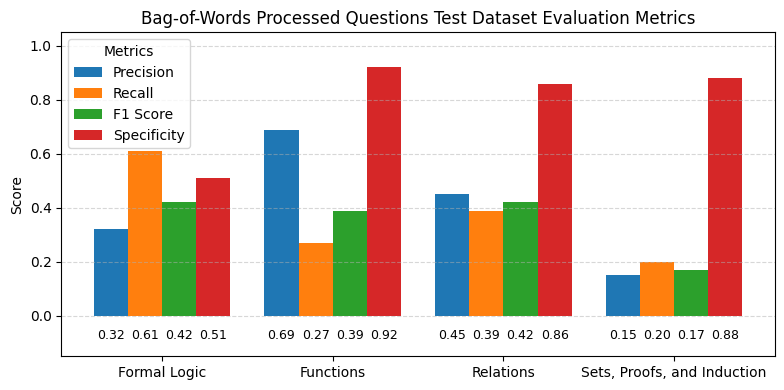

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data: 4 classes × 4 metrics
classes = ['Formal Logic', 'Functions', 'Relations', 'Sets, Proofs, and Induction']
metrics = ['Precision', 'Recall', 'F1 Score', 'Specificity']

# Random sample metric values (rows = classes, columns = metrics)
data = np.array([
    [0.32, 0.61, 0.42, 0.51],  # Class A
    [0.69, 0.27, 0.39, 0.92],  # Class B
    [0.45, 0.39, 0.42, 0.86],  # Class C
    [0.15, 0.20, 0.17, 0.88],  # Class D
])

# Plot settings
bar_width = 0.2
x = np.arange(len(classes))  # positions for each group
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(8, 4))

# Draw bars and add value labels below each bar (outside the bar)
for i in range(len(metrics)):
    bar_positions = x + i * bar_width
    bars = ax.bar(bar_positions, data[:, i], width=bar_width, label=metrics[i], color=colors[i])
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, -0.05, f'{height:.2f}',
                ha='center', va='top', fontsize=9, color='black')

# Axis configuration
ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(classes)
ax.set_ylabel('Score')
ax.set_ylim(-0.15, 1.05)  # extra space at bottom to accommodate labels
ax.set_title('Bag-of-Words Processed Questions Test Dataset Evaluation Metrics')
ax.legend(title='Metrics')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()